In [49]:
import elecboltz

import numpy as np
from scipy.constants import e, m_e, hbar, electron_volt, angstrom

import matplotlib as mpl
from matplotlib import pyplot as plt

In [50]:
# matplotlib settings
# reset defaults
mpl.rcdefaults()
# font
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['pdf.fonttype'] = 3
# plotting
mpl.rcParams['lines.linewidth'] = 3

In [51]:
def make_bandstructure(kf, three_dimensional=False, **kwargs):
    dispersion = "Ef * (kx^2 + ky^2"
    if three_dimensional:
        dispersion += " + kz^2"
    dispersion += ") / kf^2"

    a = np.pi / kf * 1e10
    coeff = hbar**2 / (2*m_e)
    Ef = coeff * kf**2 / electron_volt * 1e3
    bandstructure = elecboltz.BandStructure(
        dispersion, Ef, [a, a, a],
        band_params={'Ef': Ef, 'kf': kf * 1e-10}, **kwargs)
    bandstructure.discretize()
    return bandstructure

In [52]:
def calculate_drude(effective_mass, charge_density,
                    scattering_rate, magnetic_field):
    charge_mass = m_e * effective_mass
    omega_c = e * magnetic_field / charge_mass
    inverse_tensor = np.zeros((3, 3))
    np.fill_diagonal(inverse_tensor, scattering_rate)
    inverse_tensor[0, 1] = omega_c[2]
    inverse_tensor[1, 0] = -omega_c[2]
    inverse_tensor[0, 2] = -omega_c[1]
    inverse_tensor[2, 0] = omega_c[1]
    inverse_tensor[1, 2] = omega_c[0]
    inverse_tensor[2, 1] = -omega_c[0]
    return charge_density * e**2 / charge_mass * np.linalg.inv(inverse_tensor)

In [53]:
def loop_boltzmann_and_drude(
        conductivity, fields, scattering, charge_density):
    sigma_boltz_xx = np.empty(len(fields))
    sigma_boltz_xy = np.empty(len(fields))
    sigma_drude_xx = np.empty(len(fields))
    sigma_drude_xy = np.empty(len(fields))
    for i, field in enumerate(fields):
        conductivity.field = np.array([0, 0, field])
        conductivity.calculate()
        sigma_boltzmann = conductivity.sigma
        sigma_drude = calculate_drude(
            1, charge_density, scattering * 1e12, conductivity.field)
        sigma_boltz_xx[i] = sigma_boltzmann[0, 0]
        sigma_boltz_xy[i] = sigma_boltzmann[0, 1]
        sigma_drude_xx[i] = sigma_drude[0, 0]
        sigma_drude_xy[i] = sigma_drude[0, 1]
    return (sigma_boltz_xx, sigma_boltz_xy,
            sigma_drude_xx, sigma_drude_xy)

In [54]:
kf = 1e10
bandstructure = make_bandstructure(
    kf, three_dimensional=True, periodic=False)
charge_density = kf**3 / (3 * np.pi**2)
fields = np.linspace(0, 30, 100)
scattering = 1.0
kernel = elecboltz.kernels.LegendreKernel(
    {(0, 0): scattering / (kf * angstrom)**2})

conductivity = elecboltz.Conductivity(bandstructure, scattering_kernel=kernel)
sigma_boltz_xx, sigma_boltz_xy, sigma_drude_xx, sigma_drude_xy = loop_boltzmann_and_drude(
    conductivity, fields, scattering, charge_density)

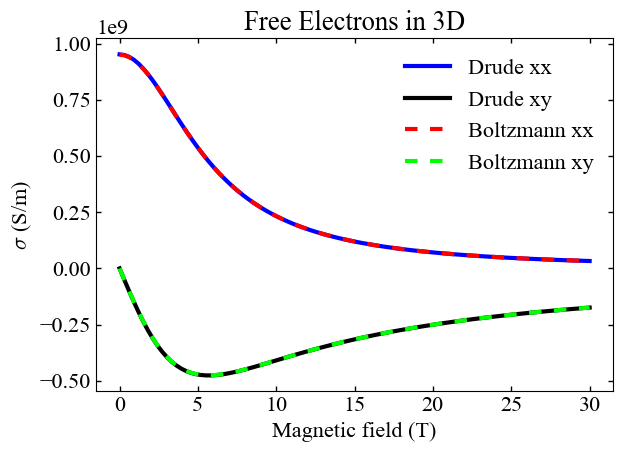

In [55]:
plt.plot(fields, sigma_drude_xx, label="Drude xx", color='blue')
plt.plot(fields, sigma_drude_xy, label="Drude xy", color='black')
plt.plot(fields, sigma_boltz_xx, label="Boltzmann xx",
         color='red', linestyle=(0, (3, 3)))
plt.plot(fields, sigma_boltz_xy, label="Boltzmann xy",
         color='lime', linestyle=(0, (3, 3)))
plt.xlabel("Magnetic field (T)")
plt.ylabel(r"$\sigma$ (S/m)")
plt.title("Free Electrons in 3D")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Drude/scattering_kernel_drude_3d.pdf", bbox_inches='tight')
plt.show()